# 259. 3Sum Smaller
https://leetcode.com/problems/3sum-smaller/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Brute Force | O(n^3) | O(1) | Check all triplets |
| **Sort + Two Pointers (Optimal)** | **O(n^2)** | **O(1)** | Fix one, use two pointers for rest |

## Methodology

Sort the array first. For each index `i`, use two pointers `lo` and `hi` on the remaining subarray. If `nums[i] + nums[lo] + nums[hi] < target`, all pairs `(lo, lo+1..hi)` are valid since the array is sorted, so add `hi - lo` to count and increment `lo`. Otherwise, decrement `hi`.

## Solutions

### C#

In [ ]:
public class Solution {
    public int ThreeSumSmaller(int[] nums, int target) {
        Array.Sort(nums);
        int count = 0;
        for (int i = 0; i < nums.Length - 2; i++) {
            int lo = i + 1, hi = nums.Length - 1;
            while (lo < hi) {
                if (nums[i] + nums[lo] + nums[hi] < target) {
                    count += hi - lo;
                    lo++;
                } else {
                    hi--;
                }
            }
        }
        return count;
    }
}

### Python

In [ ]:
class Solution:
    def threeSumSmaller(self, nums: list[int], target: int) -> int:
        nums.sort()
        count = 0
        for i in range(len(nums) - 2):
            lo, hi = i + 1, len(nums) - 1
            while lo < hi:
                if nums[i] + nums[lo] + nums[hi] < target:
                    count += hi - lo
                    lo += 1
                else:
                    hi -= 1
        return count

### Go

In [ ]:
func threeSumSmaller(nums []int, target int) int {
    sort.Ints(nums)
    count := 0
    for i := 0; i < len(nums)-2; i++ {
        lo, hi := i+1, len(nums)-1
        for lo < hi {
            if nums[i]+nums[lo]+nums[hi] < target {
                count += hi - lo
                lo++
            } else {
                hi--
            }
        }
    }
    return count
}

### Rust

In [ ]:
impl Solution {
    pub fn three_sum_smaller(mut nums: Vec<i32>, target: i32) -> i32 {
        nums.sort();
        let mut count = 0;
        let n = nums.len();
        if n < 3 { return 0; }
        for i in 0..n-2 {
            let (mut lo, mut hi) = (i + 1, n - 1);
            while lo < hi {
                if nums[i] + nums[lo] + nums[hi] < target {
                    count += (hi - lo) as i32;
                    lo += 1;
                } else {
                    hi -= 1;
                }
            }
        }
        count
    }
}

## Example Scenarios

1. **Common Case** — `nums = [-2,0,1,3], target = 2`
   **Input:** 4 elements, find triplets summing to less than 2.
   After sorting: $[-2,0,1,3]$. Triplets: $(-2,0,1)=-1<2$ and $(-2,0,3)=1<2$. Count = $2$.

2. **Slightly Complex** — `nums = [1,2,3,4,5,6], target = 12`
   **Input:** 6 sorted elements; many valid triplets.
   For each fixed $i$, the two-pointer sweep counts all pairs $(lo,hi)$ where $nums[i]+nums[lo]+nums[hi]<12$. Multiple valid windows yield a larger count.

3. **Edge Case: Time Factor** — `nums` has $n=3500$ elements (max constraint), `target = 0`, all elements positive
   **Input:** $3500$ positive numbers — no triplet sums below 0.
   The $O(n^2)$ two-pointer still iterates $\sim 3500^2/2 \approx 6 \times 10^6$ pairs. Even with zero qualifying triplets, every pair is checked.

4. **Edge Case: Space Factor** — `nums = [0,0,0], target = 1`
   **Input:** Minimum-length array (3 elements), all zeros.
   Only one triplet: $(0,0,0)=0<1$. Count = $1$. Uses $O(1)$ extra space (sort is in-place).

5. **Almost-Impossible but Plausible** — `nums = [-100,-100,...,-100]` ($n=3500$), `target = 300`
   **Input:** All elements are $-100$, so every triplet sums to $-300 < 300$.
   Count = $\binom{3500}{3} = 7{,}145{,}585{,}000$ — a huge answer. The two-pointer correctly counts $hi-lo$ at each step without enumerating each triplet.

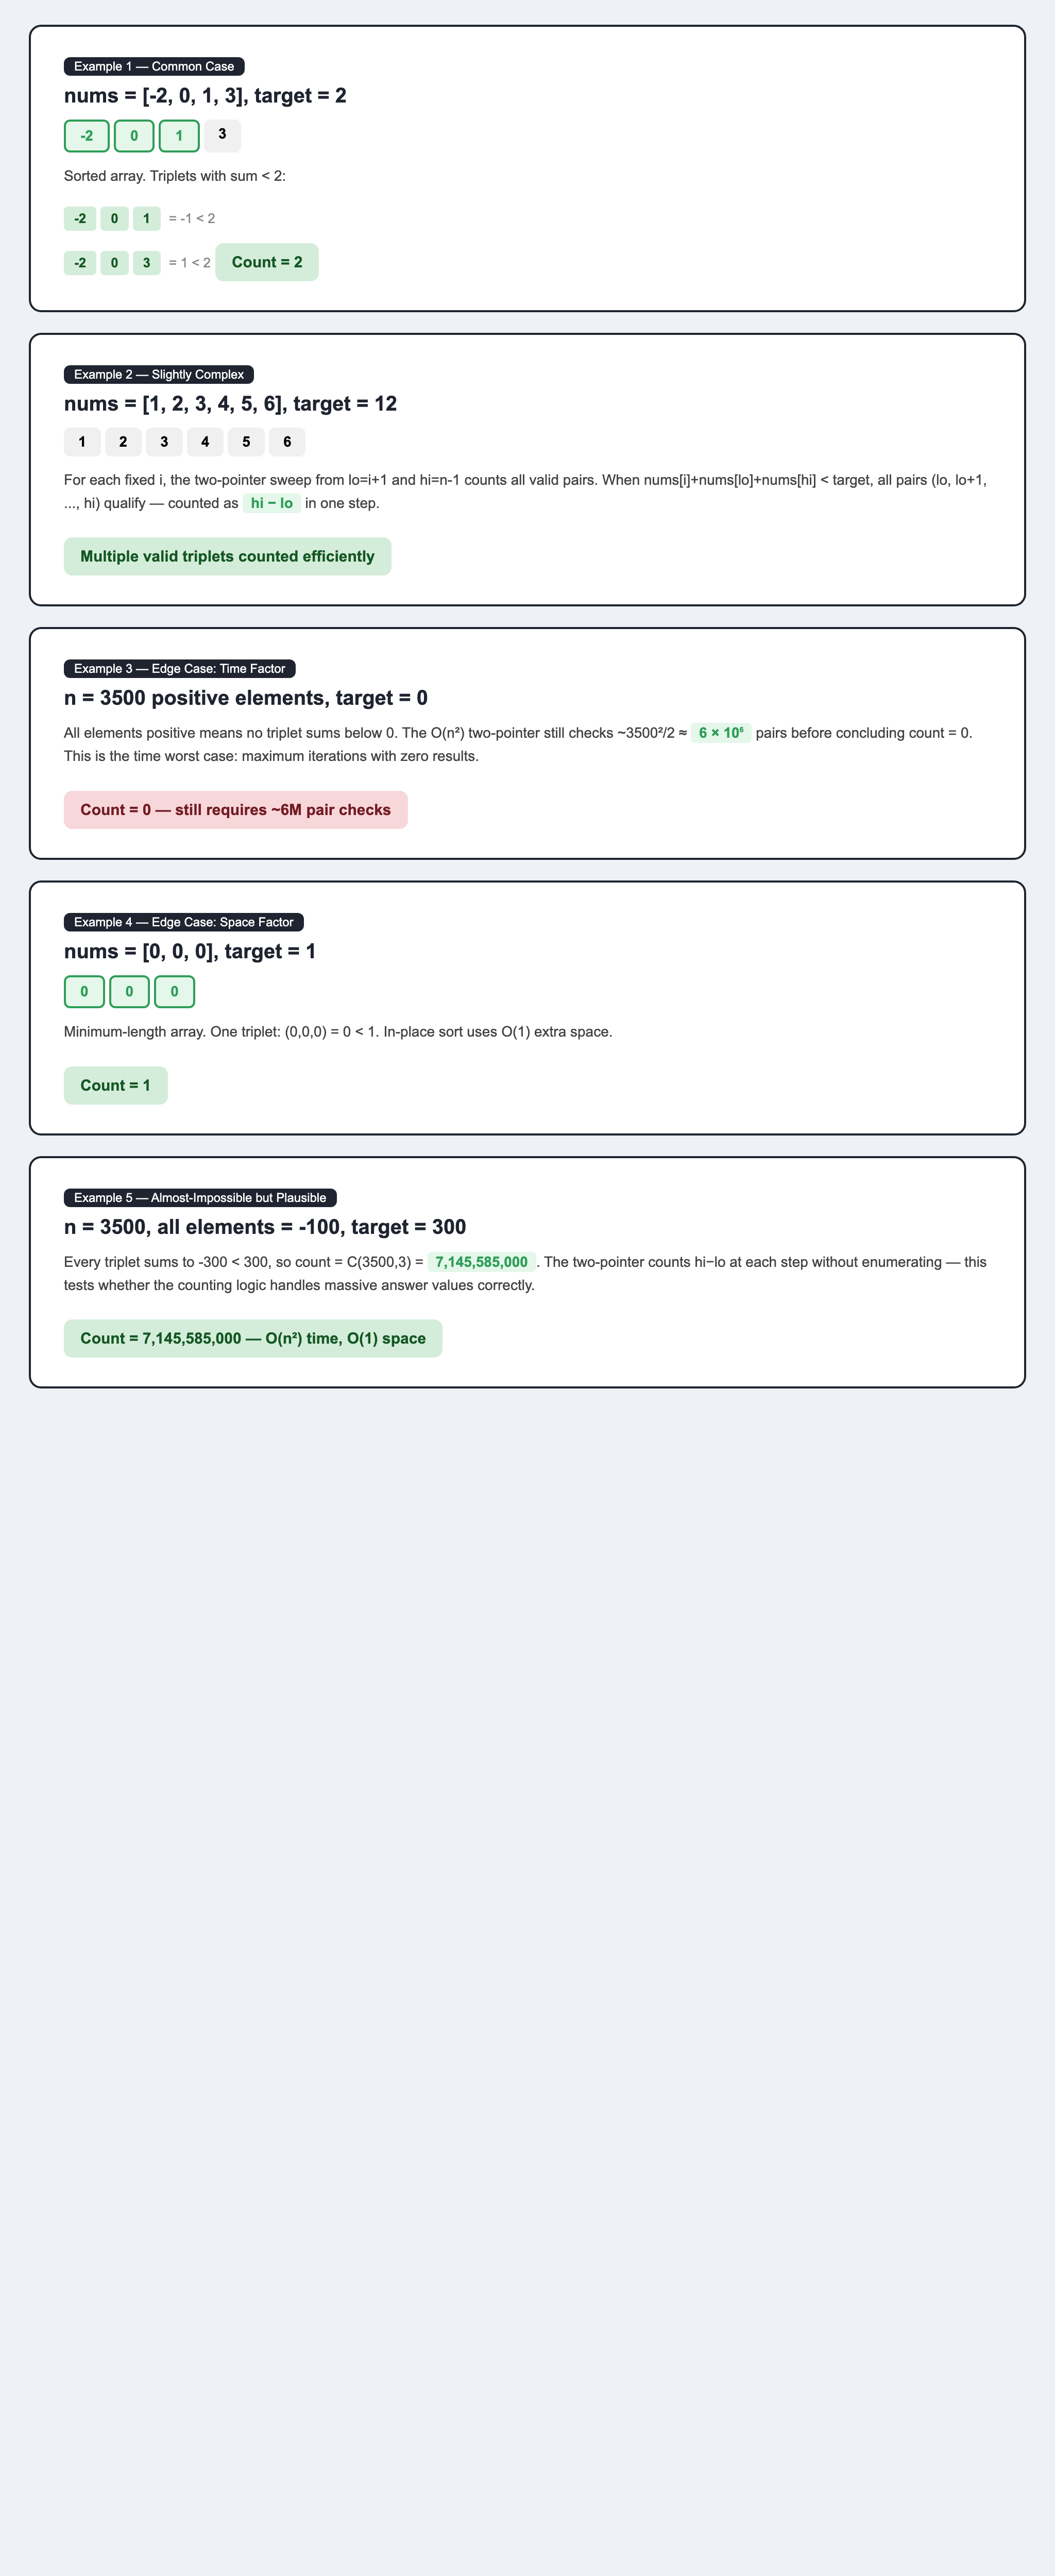